# 📍 Research-paper replication: 52-week-high momentum

## 🧭 tl;dr

George and Hwang’s 52-week-high momentum research argues that a stock’s distance from its prior 52-week high helps explain momentum profits. This notebook tests the signal as a liquid-ETF proxy: at each month start, buy the ETFs closest to their prior 252-day highs.

> Educational research only. Not financial advice. ETF results are not stock-level paper replications.

<div style="border-left: 5px solid #0891B2; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #ECFEFF; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>The key idea is not “buy the highest-return ETF.” It is “buy the assets whose current prices are already close to their own recent highs,” then compare that with ordinary trailing-return momentum.</div>


## 📚 Paper and research question

The 52-week-high momentum strategy was proposed by George and Hwang and studied in international markets by Liu, Liu, and Ma. The international paper reports that the signal remains distinct from standard Jegadeesh–Titman momentum in many markets.

Source: [The 52-Week High Momentum Strategy in International Stock Markets](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1364566).

**Research question:** does ranking ETFs by closeness to their prior 52-week high produce a useful portfolio, and does it add information beyond ordinary 12–1 momentum?


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_high_panel():
    tickers=["SPY","QQQ","EFA","EEM","TLT","IEF","GLD","DBC","VNQ","XLE","XLK","XLF"]
    try:
        panel=load_price_panel(tickers,"2006-01-01","2026-01-01")
        source="Yahoo Finance adjusted daily ETF closes"
    except Exception as exc:
        demo=make_demo_ohlcv(periods=5_000,seed=909,start="2006-01-01")["close"]
        panel=pd.DataFrame({ticker:demo*(1.0+0.02*i) for i,ticker in enumerate(tickers)},index=demo.index)
        source=f"deterministic demo ETF panel fallback ({type(exc).__name__})"
    return panel.dropna(),source


close,data_source=load_high_panel()
print(f"Data source: {data_source}")
print(f"Observations: {len(close):,} | {close.index.min().date()} to {close.index.max().date()}")
display(close.head())


Data source: Yahoo Finance adjusted daily ETF closes
Observations: 5,008 | 2006-02-06 to 2025-12-31


,DBC,EEM,EFA,GLD,IEF,QQQ,SPY,TLT,VNQ,XLE,XLF,XLK
Date,,,,,,,,,,,,
2006-02-06,19.185099,21.803116,33.987095,56.720001,48.517387,34.846840,86.932251,47.462025,27.023012,15.481526,17.145823,8.176647
2006-02-07,18.630157,21.231091,33.735306,54.599998,48.458862,34.693108,86.163185,47.237823,26.810495,14.835322,17.032133,8.153525
2006-02-08,18.550880,21.297096,33.855713,54.830002,48.429619,35.094456,86.945992,47.128330,26.691498,14.838070,17.140413,8.311515
2006-02-09,18.725290,21.352100,33.921421,56.180000,48.476437,34.761421,86.801796,47.342075,26.818996,14.499844,17.183729,8.272980
2006-02-10,18.384398,21.319098,33.844791,54.790001,48.336033,34.974899,86.959717,47.081402,26.844507,14.447604,17.281172,8.338486


## 📜 Strategy rules

At each month start:

1. Use the prior day’s close and prior 252-day high, so the current observation is not part of its own high.
2. Score each ETF as `prior close / prior 252-day high`.
3. Buy the top three scores with equal weights; hold cash if the score history is incomplete.
4. Hold positions until the next monthly rebalance.

For comparison, ordinary 12–1 momentum ranks the same assets by their trailing return while skipping the most recent month.


In [3]:

def fifty_two_week_high_weights(close, lookback=252, top_n=3):
    prior=close.shift(1)
    prior_high=prior.rolling(lookback,min_periods=lookback).max()
    score=prior/prior_high
    month=close.index.to_period("M")
    month_start=pd.Series(month,index=close.index).ne(pd.Series(month,index=close.index).shift(1))
    candidates=pd.DataFrame(0.0,index=close.index,columns=close.columns)
    for timestamp in close.index[month_start.to_numpy()]:
        valid=score.loc[timestamp].dropna()
        if len(valid)>=top_n:
            selected=valid.nlargest(top_n).index
            candidates.loc[timestamp,selected]=1.0/top_n
    weights=pd.DataFrame(np.nan,index=close.index,columns=close.columns)
    weights.loc[month_start]=candidates.loc[month_start]
    return weights.ffill().fillna(0.0)


def twelve_one_momentum_weights(close, lookback=252, skip_recent=21, top_n=3):
    score=close.shift(skip_recent).pct_change(lookback)
    month=close.index.to_period("M")
    month_start=pd.Series(month,index=close.index).ne(pd.Series(month,index=close.index).shift(1))
    candidates=pd.DataFrame(0.0,index=close.index,columns=close.columns)
    for timestamp in close.index[month_start.to_numpy()]:
        valid=score.loc[timestamp].dropna()
        if len(valid)>=top_n:
            selected=valid.nlargest(top_n).index
            candidates.loc[timestamp,selected]=1.0/top_n
    weights=pd.DataFrame(np.nan,index=close.index,columns=close.columns)
    weights.loc[month_start]=candidates.loc[month_start]
    return weights.ffill().fillna(0.0)


high_weights=fifty_two_week_high_weights(close)
momentum_weights=twelve_one_momentum_weights(close)
high_result=run_portfolio_backtest(close,high_weights,transaction_cost_bps=10.0,benchmark_returns=close["SPY"].pct_change().fillna(0.0))
momentum_result=run_portfolio_backtest(close,momentum_weights,transaction_cost_bps=10.0,benchmark_returns=close["SPY"].pct_change().fillna(0.0))
spy_hold=run_portfolio_backtest(close,pd.DataFrame({"SPY":1.0,**{c:0.0 for c in close.columns if c!="SPY"}},index=close.index),transaction_cost_bps=10.0,benchmark_returns=close["SPY"].pct_change().fillna(0.0))
splits=split_time_series(close)
periods={name:frame.index for name,frame in splits.items()}


## 📈 Results: 52-week-high signal versus ordinary momentum

The comparison keeps the universe, rebalance schedule, costs, and execution timing fixed. That isolates the ranking signal as much as a small ETF proxy allows.


In [4]:

rows=[]
for name,backtest in [("52-week-high momentum",high_result),("12–1 momentum",momentum_result),("SPY buy & hold",spy_hold)]:
    for period_name,period_index in periods.items():
        metrics=metrics_for_period(backtest,period_index)
        rows.append({"strategy":name,"period":period_name,**metrics})
summary=pd.DataFrame(rows).set_index(["strategy","period"])
display(summary[["annualized_return","annualized_volatility","sharpe_ratio","sortino_ratio","max_drawdown","calmar_ratio","annualized_turnover","number_of_trades","total_return_after_costs"]].style.format({"annualized_return":"{:.2%}","annualized_volatility":"{:.2%}","sharpe_ratio":"{:.2f}","sortino_ratio":"{:.2f}","max_drawdown":"{:.2%}","calmar_ratio":"{:.2f}","annualized_turnover":"{:.2f}","number_of_trades":"{:.0f}","total_return_after_costs":"{:.2%}"}))


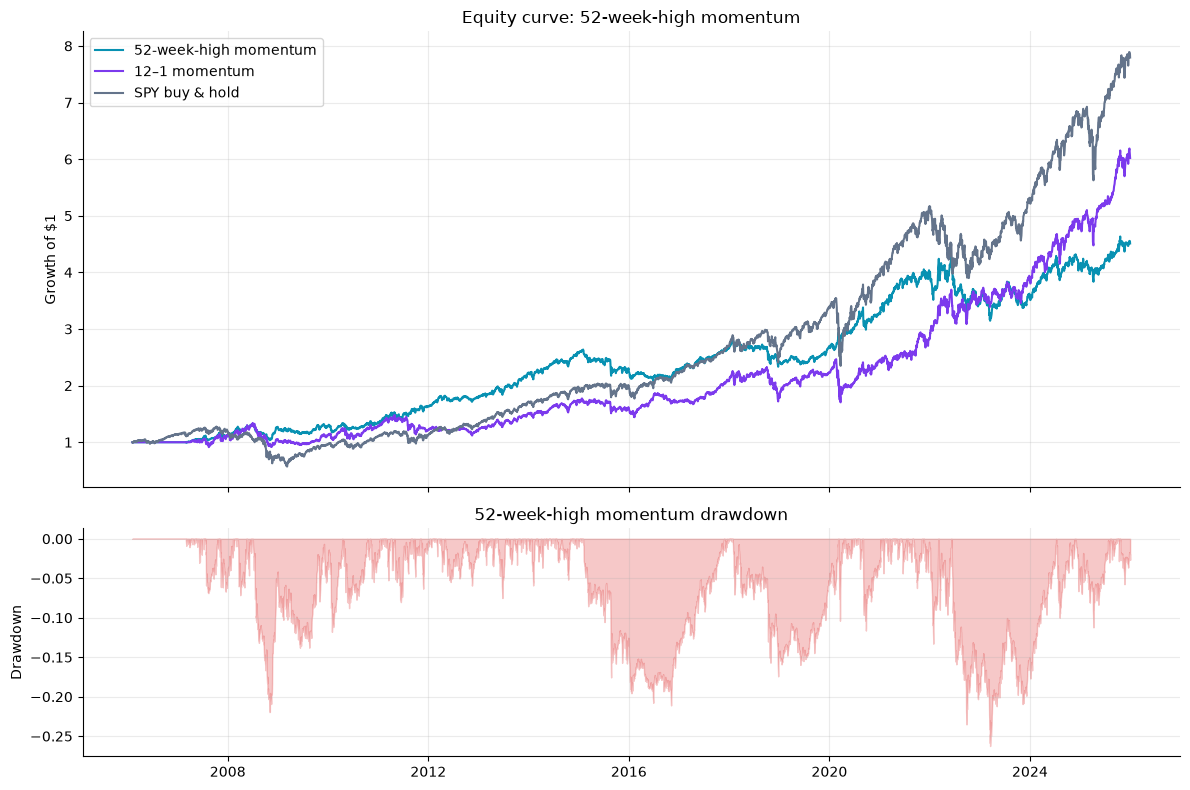

In [5]:

fig,axes=plt.subplots(2,1,figsize=(12,8),sharex=True,gridspec_kw={"height_ratios":[2,1]})
for backtest,label,color in [(high_result,"52-week-high momentum","#0891B2"),(momentum_result,"12–1 momentum","#7C3AED"),(spy_hold,"SPY buy & hold","#64748B")]:
    axes[0].plot(backtest.frame.index,backtest.frame.equity/backtest.frame.equity.iloc[0],label=label,color=color)
axes[0].set_title("Equity curve: 52-week-high momentum")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(high_result.frame.index,high_result.frame.drawdown,0,color="#DC2626",alpha=0.25)
axes[1].set_title("52-week-high momentum drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


## 🧪 Robustness checks

The paper’s signal is simple, but the choice of lookback and number of holdings can still matter. We show nearby settings and keep the stated 252-day / top-three version as the primary test.


In [6]:

grid_rows=[]
for lookback,top_n in itertools.product([126,252], [1,3,5]):
    candidate_weights=fifty_two_week_high_weights(close,lookback,top_n)
    candidate=run_portfolio_backtest(close,candidate_weights,transaction_cost_bps=10.0,benchmark_returns=close["SPY"].pct_change().fillna(0.0))
    validation=metrics_for_period(candidate,periods["validation"])
    test=metrics_for_period(candidate,periods["test"])
    grid_rows.append({"lookback":lookback,"top_n":top_n,"validation_sharpe":validation["sharpe_ratio"],"validation_return":validation["annualized_return"],"test_sharpe":test["sharpe_ratio"],"test_return":test["annualized_return"],"test_drawdown":test["max_drawdown"]})
sensitivity=pd.DataFrame(grid_rows).sort_values("validation_sharpe",ascending=False)
display(sensitivity.style.format({"validation_sharpe":"{:.2f}","validation_return":"{:.2%}","test_sharpe":"{:.2f}","test_return":"{:.2%}","test_drawdown":"{:.2%}"}))


,lookback,top_n,validation_sharpe,validation_return,test_sharpe,test_return,test_drawdown
2,126,5,1.07,12.97%,0.50,5.92%,-21.84%
5,252,5,0.86,10.77%,0.53,6.36%,-19.98%
4,252,3,0.82,10.37%,0.27,3.02%,-26.25%
1,126,3,0.82,9.92%,0.39,4.85%,-23.69%
0,126,1,0.47,6.11%,0.38,5.43%,-31.31%
3,252,1,0.45,6.06%,0.44,7.03%,-30.00%


In [7]:

cost_rows=[]
for cost_bps in [0,10,25,50]:
    cost_result=run_portfolio_backtest(close,high_weights,transaction_cost_bps=cost_bps,benchmark_returns=close["SPY"].pct_change().fillna(0.0))
    metrics=metrics_for_period(cost_result,periods["test"])
    cost_rows.append({"transaction_cost_bps":cost_bps,"test_return":metrics["annualized_return"],"test_sharpe":metrics["sharpe_ratio"],"test_drawdown":metrics["max_drawdown"],"test_turnover":metrics["annualized_turnover"]})
display(pd.DataFrame(cost_rows).style.format({"test_return":"{:.2%}","test_sharpe":"{:.2f}","test_drawdown":"{:.2%}","test_turnover":"{:.2f}"}))


,transaction_cost_bps,test_return,test_sharpe,test_drawdown,test_turnover
0,0,4.29%,0.35,-25.60%,12.24
1,10,3.02%,0.27,-26.25%,12.24
2,25,1.14%,0.15,-27.20%,12.24
3,50,-1.92%,-0.05,-28.78%,12.24


## ⚖️ What went well / what went wrong

### ✅ What went well

- The signal is intuitive and less dependent on arbitrary return cutoffs than ordinary momentum.
- The comparison with 12–1 momentum uses the same ETF universe and schedule.
- The strategy is easy for a beginner to inspect: every score is a price divided by a prior rolling high.

### ⚠️ What went wrong or remains uncertain

- The original paper uses individual stocks and broader international samples; ETF behavior can be very different.
- A “near the high” score can reward crowded, expensive, or late-stage trends.
- Sector and asset-class ETFs have unequal histories and different volatility, so equal weighting is not a neutral choice.
- The test does not include the paper’s stock-level controls, delistings, or portfolio breadth.

**Bottom line:** 52-week-high momentum is a distinct ranking hypothesis, but its evidence here is proxy evidence. Compare it with ordinary momentum and inspect the untouched test rather than relying on the paper’s historical average.
